In [2]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(readr)

In [3]:
load("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_prediction.Rdata")

In [4]:
metabolite  <- read.csv("/vol/projects/yzhang/500FG_aging/input/metabolite/metabolite_rank_normalized.csv",row.names=1,check.names=FALSE) 
head(metabolite)
dim(metabolite)

Rows: 1596 Columns: 479
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (5): database_identifier, chemical_formula, smiles, inchi, metabolite_...
dbl (460): mass_to_charge, reliability, HV001, HV002, HV003, HV004, HV005, H...
lgl  (14): fragmentation, modifications, charge, retention_time, taxid, spec...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


database_identifier,chemical_formula,smiles,inchi,metabolite_identification,mass_to_charge,fragmentation,modifications,charge,retention_time,⋯,HV525,HV526,HV527,HV528,HV529,HV530,HV531,HV532,HV533,HV534
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CHEBI:10022,C15H20O6,[H][C@@]12O[C@]3([H])C=C(C)C(=O)[C@@H](O)[C@]3(CO)[C@@](C)(C[C@H]1O)[C@]21CO1,"InChI=1S/C15H20O6/c1-7-3-9-14(5-16,11(19)10(7)18)13(2)4-8(17)12(21-9)15(13)6-20-15/h3,8-9,11-12,16-17,19H,4-6H2,1-2H3/t8-,9-,11-,12-,13-,14-,15+/m1/s1",Deoxynivalenol,295.1191,NA,NA,NA,NA,⋯,18349.0,44987.5,22414.5,19734.0,21075.5,16550.0,20302.0,12916.5,13331.0,36608.0
CHEBI:10075,C16H16O3,COc1cc(O)ccc1C\C=C\c1ccc(O)cc1,"InChI=1S/C16H16O3/c1-19-16-11-15(18)10-7-13(16)4-2-3-12-5-8-14(17)9-6-12/h2-3,5-11,17-18H,4H2,1H3/b3-2+",Xenognosin A,255.1038,NA,NA,NA,NA,⋯,17442.5,23112.5,18458.0,15341.0,17501.0,12886.5,13475.0,20116.5,18011.5,18617.5
CHEBI:10137,C17H26O3,CCCCCCCC(=O)CCc1ccc(O)c(OC)c1,"InChI=1S/C17H26O3/c1-3-4-5-6-7-8-15(18)11-9-14-10-12-16(19)17(13-14)20-2/h10,12-13,19H,3-9,11H2,1-2H3",1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,277.1809,NA,NA,NA,NA,⋯,410828.5,424573.0,784687.0,294914.5,864931.0,356691.0,424070.5,382228.5,465130.0,370595.5
CHEBI:10366,C7H14O4,[H]C([H])(C=O)[C@]([H])(OC)[C@]([H])(O)[C@@]([H])(C)O,"InChI=1S/C7H14O4/c1-5(9)7(10)6(11-2)3-4-8/h4-7,9-10H,3H2,1-2H3/t5-,6+,7-/m1/s1",Cymarose,161.0819,NA,NA,NA,NA,⋯,10493.0,10690.0,10907.5,9893.0,11671.5,10216.5,11271.0,10342.5,10849.5,9935.5
CHEBI:10368,C7H14O5,[H][C@](C)(O)[C@]([H])(O)[C@]([H])(OC)[C@@]([H])(O)C=O,"InChI=1S/C7H14O5/c1-4(9)6(11)7(12-2)5(10)3-8/h3-7,9-11H,1-2H3/t4-,5+,6+,7-/m1/s1",Digitalose,177.0772,NA,NA,NA,NA,⋯,17688.0,14362.5,16077.5,14465.5,19710.0,14843.5,14253.5,15513.0,13962.5,13581.0
CHEBI:10432,C10H8O,Oc1ccc2ccccc2c1,"InChI=1S/C10H8O/c11-10-6-5-8-3-1-2-4-9(8)7-10/h1-7,11H",2-Naphthol,143.0493,NA,NA,NA,NA,⋯,24687.0,20415.5,23917.5,19506.5,20907.0,18360.0,18922.0,19580.0,17712.0,16752.5


[1] 1596  479

,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV011,⋯,HV525,HV526,HV527,HV528,HV529,HV530,HV531,HV532,HV533,HV534
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Deoxynivalenol,20325.5,20604.5,30331.0,14997.0,13991.0,15048.5,17086.0,19065.5,36626.5,20855.0,⋯,18349.0,44987.5,22414.5,19734.0,21075.5,16550.0,20302.0,12916.5,13331.0,36608.0
Xenognosin A,16030.5,18831.5,24791.5,17869.5,15543.5,17714.5,14684.5,16868.0,16668.0,16151.0,⋯,17442.5,23112.5,18458.0,15341.0,17501.0,12886.5,13475.0,20116.5,18011.5,18617.5
1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,388846.0,324465.0,331666.5,374568.5,318622.0,387658.5,434873.0,400345.5,276148.0,258801.0,⋯,410828.5,424573.0,784687.0,294914.5,864931.0,356691.0,424070.5,382228.5,465130.0,370595.5
Cymarose,10987.5,9602.0,9588.0,9072.5,8679.5,9029.5,10611.0,9393.0,9817.0,9269.5,⋯,10493.0,10690.0,10907.5,9893.0,11671.5,10216.5,11271.0,10342.5,10849.5,9935.5
Digitalose,14547.0,12737.0,13865.5,13150.0,13636.5,13891.5,15179.5,12754.5,13344.0,14238.0,⋯,17688.0,14362.5,16077.5,14465.5,19710.0,14843.5,14253.5,15513.0,13962.5,13581.0
2-Naphthol,21882.5,19354.5,17533.0,20510.5,18029.0,21299.0,21016.5,21188.5,18381.5,19498.5,⋯,24687.0,20415.5,23917.5,19506.5,20907.0,18360.0,18922.0,19580.0,17712.0,16752.5


[1] 1596  458

[1] FALSE

[1]  458 1596

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,Dihydroisomorphine-3-glucuronide,"7,11-Bisdeacetylvaltrate 7-(3-methylpentanoate) 11-(3-hydroxy-3-methylbutanoate)","(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,20325.5,16030.5,388846.0,10987.5,14547.0,21882.5,14201.0,14650.5,8620.5,11428,⋯,13142.5,14167.0,9401.5,17702.5,17702.5,10169.5,17017.0,19663.0,30233.5,126298.0
HV002,20604.5,18831.5,324465.0,9602.0,12737.0,19354.5,20310.0,14790.0,8081.0,14077,⋯,11661.0,34008.5,9580.5,16853.5,16853.5,13238.5,18201.0,20731.0,35445.0,60949.5
HV003,30331.0,24791.5,331666.5,9588.0,13865.5,17533.0,19598.0,14537.0,7405.0,11285,⋯,20263.0,14685.0,23445.5,20627.5,20627.5,15032.5,15631.5,23595.0,36253.0,48469.0
HV004,14997.0,17869.5,374568.5,9072.5,13150.0,20510.5,18216.5,16288.0,7810.0,12780,⋯,15027.5,12052.0,9388.5,16298.0,16298.0,12874.0,18982.0,21619.5,34825.5,63373.0
HV005,13991.0,15543.5,318622.0,8679.5,13636.5,18029.0,19823.5,14830.5,8571.0,15183,⋯,36945.0,13568.5,12124.0,35662.5,35662.5,16768.0,16786.5,19816.5,35610.5,42202.5
HV006,15048.5,17714.5,387658.5,9029.5,13891.5,21299.0,20080.0,15122.5,7532.0,11903,⋯,29487.0,13197.5,10096.5,16939.0,16939.0,13932.5,15564.0,18517.0,33008.5,272100.0


In [11]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(metabolite_trans), basicPhenos$ID_500fg) 
length(idx) #458samples
metabolite_filter = metabolite_trans[which(rownames(metabolite_trans) %in% idx),]
head(metabolite_filter)  #458samples,1596 metabolite
dim(metabolite_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(metabolite_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(metabolite_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(metabolite_trans))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples
write.csv(metabolite_filter, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/common_metabolite_filter_age.csv")
write.csv(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/common_basicPhenos_filter_match_metabolite_age.csv")
save(metabolite_filter, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/common_metabolite_filter_age.RData")
save(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/input/metabolite/common_basicPhenos_filter_match_metabolite_age.RData")

[1] 451

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,Dihydroisomorphine-3-glucuronide,"7,11-Bisdeacetylvaltrate 7-(3-methylpentanoate) 11-(3-hydroxy-3-methylbutanoate)","(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,20325.5,16030.5,388846.0,10987.5,14547.0,21882.5,14201.0,14650.5,8620.5,11428,⋯,13142.5,14167.0,9401.5,17702.5,17702.5,10169.5,17017.0,19663.0,30233.5,126298.0
HV002,20604.5,18831.5,324465.0,9602.0,12737.0,19354.5,20310.0,14790.0,8081.0,14077,⋯,11661.0,34008.5,9580.5,16853.5,16853.5,13238.5,18201.0,20731.0,35445.0,60949.5
HV003,30331.0,24791.5,331666.5,9588.0,13865.5,17533.0,19598.0,14537.0,7405.0,11285,⋯,20263.0,14685.0,23445.5,20627.5,20627.5,15032.5,15631.5,23595.0,36253.0,48469.0
HV004,14997.0,17869.5,374568.5,9072.5,13150.0,20510.5,18216.5,16288.0,7810.0,12780,⋯,15027.5,12052.0,9388.5,16298.0,16298.0,12874.0,18982.0,21619.5,34825.5,63373.0
HV005,13991.0,15543.5,318622.0,8679.5,13636.5,18029.0,19823.5,14830.5,8571.0,15183,⋯,36945.0,13568.5,12124.0,35662.5,35662.5,16768.0,16786.5,19816.5,35610.5,42202.5
HV006,15048.5,17714.5,387658.5,9029.5,13891.5,21299.0,20080.0,15122.5,7532.0,11903,⋯,29487.0,13197.5,10096.5,16939.0,16939.0,13932.5,15564.0,18517.0,33008.5,272100.0


[1]  451 1596

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
6,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1


[1] 451  18

[1] 0

Warning message in basicPhenos_filter_match$ID_500fg == rownames(metabolite_trans):
“longer object length is not a multiple of shorter object length”


[1] 193

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
349,304,HV001,male,27,178,70,22.09317,Married,University degree,European,Once a month,Yes,No,24,7,204,2013,Group 5
331,305,HV002,male,26,178,68,21.46194,Cohabitation,University degree,European,Rarely,No,Yes,24,7,204,2013,Group 4
263,257,HV003,female,24,173,68,22.72044,Married,University degree,European,Rarely,Yes,Yes,26,8,236,2013,Group 4
79,258,HV004,female,20,173,65,21.71807,Married,University degree,European,Rarely,Yes,No,26,8,236,2013,Group 2
180,254,HV005,female,22,178,64,20.19947,Married,University student,European,Once a month,Yes,Yes,5,9,245,2013,Group 3
285,530,HV006,female,24,168,58,20.54989,Married,University degree,European,Rarely,Yes,No,NA,NA,NA,NA,Group 4


[1] 451  18

In [4]:
metabolite_age <- cbind(metabolite_filter, Age = basicPhenos_filter_match$Age)
head(metabolite_age)
dim(metabolite_age)

,Deoxynivalenol,Xenognosin A,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,Cymarose,Digitalose,2-Naphthol,5-Hydroxy-7-(4-hydroxy-3-methoxyphenyl)-1-phenyl-3-heptanone,"N,N'-Diacetylchitobiosyldiphosphodolichol",10-Undecenal,Vitamin A,⋯,"7,11-Bisdeacetylvaltrate 7-(3-methylpentanoate) 11-(3-hydroxy-3-methylbutanoate)","(7'x,8'x)-4,7'-Epoxy-3,8'-bilign-7-ene-3,5'-dimethoxy-4',9,9'-triol,3-(4-hydroxyphenyl)-1-[2,4,6-trihydroxy-3-(4-hydroxy-3-methylbut-2-en-1-yl)phenyl]propan-1-one",DG(15:0/18:0/0:0),"DG(15:0/20:3(5Z,8Z,11Z)/0:0)","1alpha,3beta,22R-Trihydroxyergosta-5,24E-Dien-26-OicAcid3-O-B-D-Glucoside26-O-B-D-Glucosyl Ester",Cyanidin 3-O-[b-D-Xylopyranosyl-(1->2)-[(4-hydroxybenzoyl)-(->6)-b-D-glucopyranoside],"TG(18:3(9Z,12Z,15Z)/14:0/22:6(4Z,7Z,10Z,13Z,16Z,19Z))[iso6]",Araliasaponin II,Quinic acid,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV001,20325.5,16030.5,388846.0,10987.5,14547.0,21882.5,14201.0,14650.5,8620.5,11428,⋯,14167.0,9401.5,17702.5,17702.5,10169.5,17017.0,19663.0,30233.5,126298.0,27
HV002,20604.5,18831.5,324465.0,9602.0,12737.0,19354.5,20310.0,14790.0,8081.0,14077,⋯,34008.5,9580.5,16853.5,16853.5,13238.5,18201.0,20731.0,35445.0,60949.5,26
HV003,30331.0,24791.5,331666.5,9588.0,13865.5,17533.0,19598.0,14537.0,7405.0,11285,⋯,14685.0,23445.5,20627.5,20627.5,15032.5,15631.5,23595.0,36253.0,48469.0,24
HV004,14997.0,17869.5,374568.5,9072.5,13150.0,20510.5,18216.5,16288.0,7810.0,12780,⋯,12052.0,9388.5,16298.0,16298.0,12874.0,18982.0,21619.5,34825.5,63373.0,20
HV005,13991.0,15543.5,318622.0,8679.5,13636.5,18029.0,19823.5,14830.5,8571.0,15183,⋯,13568.5,12124.0,35662.5,35662.5,16768.0,16786.5,19816.5,35610.5,42202.5,22
HV006,15048.5,17714.5,387658.5,9029.5,13891.5,21299.0,20080.0,15122.5,7532.0,11903,⋯,13197.5,10096.5,16939.0,16939.0,13932.5,15564.0,18517.0,33008.5,272100.0,24


[1]  451 1597

In [5]:
##perform 100 times
# Custom function to train and evaluate the model
train_and_evaluate <- function(data, seed, iteration) {
  set.seed(seed)
  
  # Split data into training and validation sets
  splitSample <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[splitSample, ]
  validation <- data[-splitSample, ]
  
  # Set up the grid for hyperparameter tuning
  # netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
  netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))    
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5) 
  
  # Train the model
  netFit <- train(Age ~ ., data = training, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions on training and validation sets
  train_predictions <- predict(netFit, newdata = training)
  val_predictions <- predict(netFit, newdata = validation)
  
    # Save predicted age for each sample   
   pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training),
      Age_true = training$Age,
      Age_pred = as.numeric(train_predictions),
      stringsAsFactors = FALSE
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation),
      Age_true = validation$Age,
      Age_pred = as.numeric(val_predictions),
      stringsAsFactors = FALSE
    )
  )
  # Compute performance metrics for training set
  train_rmse <- sqrt(mean((training$Age - train_predictions)^2))  # RMSE
  train_mse <- mean((training$Age - train_predictions)^2)         # MSE
  train_r_squared <- cor(training$Age, train_predictions)^2       # R²
  
  # Compute performance metrics for validation set
  val_rmse <- sqrt(mean((validation$Age - val_predictions)^2))    # RMSE
  val_mse <- mean((validation$Age - val_predictions)^2)           # MSE
  val_r_squared <- cor(validation$Age, val_predictions)^2         # R²
  
  # Return metrics
  list(
    train_RMSE = train_rmse,
    train_MSE = train_mse,
    train_R2 = train_r_squared,
    val_RMSE = val_rmse,
    val_MSE = val_mse,
    val_R2 = val_r_squared,
    best_model = netFit,
    # selected_features = selected_features,
    predictions = pred_df
  )
}


In [6]:
# Run the training process 100 times
set.seed(1)
results <- lapply(1:100, function(i) train_and_evaluate(metabolite_age, seed = i, iteration = i))

# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)

# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values)),
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values))
)

# Print summary
head(metrics_summary)

,Metric,Mean,SD
,<chr>,<dbl>,<dbl>
1,Train RMSE,5.8504830,0.81417309
2,Validation RMSE,8.4609760,1.07251292
3,Train MSE,34.8844001,8.63400520
4,Validation MSE,72.7268954,20.19953122
5,Train R²,0.7906739,0.05128853
6,Validation R²,0.5214369,0.08524933


In [8]:
saveRDS(results, "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/metabolite_prediction_results.rds")
all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/metabolite_pre_age_elasticnet_orign_sample_feature.csv", row.names = FALSE)

png 
  2

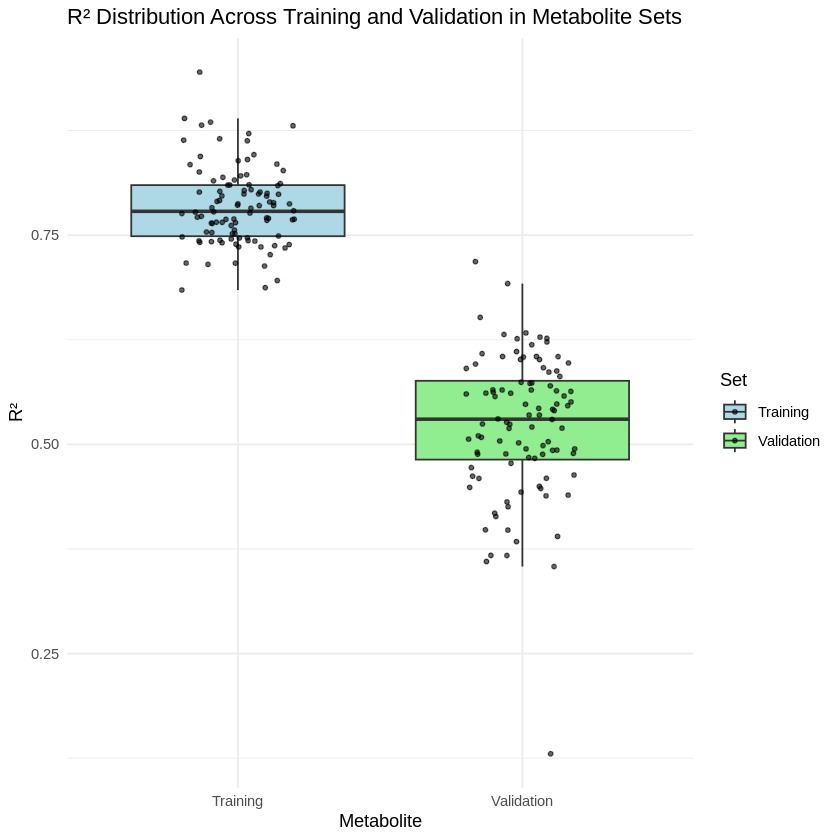

In [14]:
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
ppi <- 300
png("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_cross_validation.png", 
    width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Metabolite Sets",
       x = "Metabolite",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)

In [15]:
save.image(file="/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_prediction.Rdata")